# Non-canonical Splice Site Prediction

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [2]:
from alphagenome_pytorch.plotting.splicing import (
    SPLICE_CLASS_NAMES,
    BACKGROUND_CLASS,
    CLASS_LABELS,
    CLASS_COLORS,
    TISSUE_COLORS,
    TISSUE_ORDER,
    SPECIES_ORDER,
    SPECIES,
    SPECIES_SCI,
    CHR_SIZES,
)
from alphagenome_pytorch.evaluation.splicing import fast_auprc

In [ ]:
home = os.path.expanduser("~")
work_dir = f"{home}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/"
ann_data_dir = f"{home}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/"
model = "lora_32_human_mouse_rat_rabbit_opossum"
model_dir = os.path.join(work_dir, model)

subsets = ["intersect_protein_coding"]  # "intersect_usage", "intersect_protein_coding", "gtf_protein_coding"
subset = subsets[0]
pred_dir = f"preds_all_{subset}"
conf_fn = f"data_config_{subset}.json"
data_config_path = os.path.join(ann_data_dir, conf_fn)
data_config = json.load(open(data_config_path, "r"))

## Annotate splice sites with canonical type

For each species, extract the 2-nt dinucleotide at each donor/acceptor site from the
reference genome.

Extraction rules (0-based position `P` from the annotation parquet):

| SiteType | Genomic fetch | Strand correction |
|----------|---------------|------------------|
| Donor+   | `genome[P+1 : P+3]` | — |
| Acceptor+ | `genome[P-2 : P]` | — |
| Donor-   | `genome[P-2 : P]` | reverse complement |
| Acceptor- | `genome[P+1 : P+3]` | reverse complement |

Canonical dinucleotides (in transcript 5'→3' direction):
- Donors: **GT** (U2, major), **GC** (U2, rare), **AT** (U12, minor)
- Acceptors: **AG** (U2 and U12), **AC** (U12, minor)

Sites with any other dinucleotide are labelled **non-canonical**.

In [5]:
COMPLEMENT = str.maketrans("ACGTacgt", "TGCAtgca")

def _rev_comp(seq: str) -> str:
    return seq.translate(COMPLEMENT)[::-1]


def get_splice_dinucleotide(pos: int, site_type: str, fasta_chrom) -> tuple[str | None, str | None]:
    """Return (dinucleotide, canonical_type) for a splice site.

    pos       : 0-based position from the annotation parquet
    site_type : one of Donor+, Acceptor+, Donor-, Acceptor-
    fasta_chrom: pyfaidx chromosome object (supports 0-based Python slicing)
    """
    try:
        if site_type == "Donor+":
            raw = str(fasta_chrom[pos + 1 : pos + 3]).upper()
            dn = raw
        elif site_type == "Acceptor+":
            if pos < 2:
                return None, None
            raw = str(fasta_chrom[pos - 2 : pos]).upper()
            dn = raw
        elif site_type == "Donor-":
            if pos < 2:
                return None, None
            raw = str(fasta_chrom[pos - 2 : pos]).upper()
            dn = _rev_comp(raw)
        elif site_type == "Acceptor-":
            raw = str(fasta_chrom[pos + 1 : pos + 3]).upper()
            dn = _rev_comp(raw)
        else:
            return None, None
    except Exception:
        return None, None

    if len(dn) != 2:
        return dn, None

    # Canonical classification
    if site_type.startswith("Donor"):
        if dn == "GT":
            ct = "GT"
        elif dn == "GC":
            ct = "GC"
        elif dn == "AT":
            ct = "AT"
        else:
            ct = "non-canonical"
    else:  # Acceptor
        if dn == "AG":
            ct = "AG"
        elif dn == "AC":
            ct = "AC"
        else:
            ct = "non-canonical"

    return dn, ct

In [6]:
%%time
import pyfaidx

save = True
canonical_ann = {}  # sp -> annotated DataFrame

for sp in ["human", "mouse", "rat", "rabbit", "opossum"]:
    sp_cfg = data_config.get(sp, {})

    genome_path = os.path.expanduser(sp_cfg.get("genome", ""))
    ann_fn      = os.path.expanduser(sp_cfg.get("annotation_parquet", ""))

    if not os.path.exists(genome_path):
        print(f"[{sp}] Genome FASTA not found: {genome_path}")
        continue
    if not os.path.exists(ann_fn):
        print(f"[{sp}] Annotation parquet not found: {ann_fn}")
        continue

    # Re-use cached file if already computed
    canonical_fn = ann_fn.replace(".parquet", "_with_canonical_type.parquet")
    if os.path.exists(canonical_fn):
        print(f"[{sp}] Loading cached canonical annotation: {canonical_fn}")
        canonical_ann[sp] = pd.read_parquet(canonical_fn)
        print(canonical_ann[sp].groupby(["SiteType", "canonical_type"]).size().reset_index(name="n"))
        continue

    ann_df = pd.read_parquet(ann_fn)
    print(f"[{sp}] Loaded annotation: {len(ann_df):,} sites — extracting dinucleotides...")

    fasta = pyfaidx.Fasta(genome_path)

    dinucleotides = []
    canonical_types = []

    for _, row in tqdm(ann_df.iterrows(), total=len(ann_df), desc=sp):
        chrom     = str(row["Chromosome"])
        pos       = int(row["Position"])
        site_type = str(row["SiteType"])

        if chrom not in fasta:
            dinucleotides.append(None)
            canonical_types.append(None)
            continue

        dn, ct = get_splice_dinucleotide(pos, site_type, fasta[chrom])
        dinucleotides.append(dn)
        canonical_types.append(ct)

    fasta.close()

    ann_df["dinucleotide"]  = dinucleotides
    ann_df["canonical_type"] = canonical_types
    canonical_ann[sp] = ann_df

    if save:
        ann_df.to_parquet(canonical_fn, index=False)
        print(f"[{sp}] Saved to {canonical_fn}")

    print(f"\n[{sp}] Dinucleotide distribution:")
    print(ann_df.groupby(["SiteType", "canonical_type", "dinucleotide"]).size().reset_index(name="n").to_string())

[human] Loading cached canonical annotation: /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/splice_sites_intersect_protein_coding_with_canonical_type.parquet
     SiteType canonical_type       n
0      Donor+             AT     101
1      Donor+             GC    1771
2      Donor+             GT  110885
3   Acceptor+             AC     108
4   Acceptor+             AG  110917
5   Acceptor+  non-canonical       5
6      Donor-             AT     125
7      Donor-             GC    1730
8      Donor-             GT  109810
9   Acceptor-             AC     141
10  Acceptor-             AG  109490
11  Acceptor-  non-canonical       8
[mouse] Loading cached canonical annotation: /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Mus_musculus/splice_sites_intersect_protein_coding_with_canonical_type.parquet
     SiteType canonical_type      n
0      Donor+             AT    103
1      Donor+             GC    850
2      Donor+             GT  90516
3

## Evaluate splice classification by canonical type

Load the per-site classification predictions (produced by `splice_model_eval.ipynb`) and
merge each position with its canonical type.

In [8]:
%%time
canonical_preds = {}  # sp -> merged DataFrame

for sp in ["human", "mouse", "rat", "rabbit", "opossum"]:
    preds_file = os.path.join(work_dir, model, pred_dir, sp, f"predictions_{sp}.parquet")
    if not os.path.exists(preds_file):
        print(f"[{sp}] Predictions parquet missing: {preds_file}")
        continue

    preds_df = pd.read_parquet(preds_file)

    # Load canonical annotation (from above or from disk)
    if sp not in canonical_ann:
        sp_cfg = data_config.get(sp, {})
        ann_fn = os.path.expanduser(sp_cfg.get("annotation_parquet", ""))
        canonical_fn = ann_fn.replace(".parquet", "_with_canonical_type.parquet")
        if os.path.exists(canonical_fn):
            canonical_ann[sp] = pd.read_parquet(canonical_fn)
        else:
            print(f"[{sp}] Canonical type annotation not found, run the cell above first.")
            continue

    ann_df = (
        canonical_ann[sp][["Chromosome", "Position", "SiteType", "dinucleotide", "canonical_type"]]
        .rename(columns={"Chromosome": "chrom", "Position": "position"})
    )

    merged = preds_df.merge(ann_df, on=["chrom", "position"], how="left")
    canonical_preds[sp] = merged

    n_splice = (merged["class_label"] < 4).sum()
    n_canon  = merged["canonical_type"].notna().sum()
    print(f"[{sp}] {len(merged):,} positions — {n_splice:,} splice sites — {n_canon:,} with canonical type")

[human] 63,665,914 positions — 20,416 splice sites — 20,416 with canonical type
[mouse] 45,598,359 positions — 15,374 splice sites — 15,374 with canonical type
[rat] 38,565,256 positions — 12,914 splice sites — 12,914 with canonical type
[rabbit] 64,437,139 positions — 15,155 splice sites — 15,155 with canonical type
[opossum] 55,105,436 positions — 13,417 splice sites — 13,417 with canonical type
CPU times: user 47.3 s, sys: 16.4 s, total: 1min 3s
Wall time: 1min 19s


### AUPRC by canonical type and class

For each species, class, and canonical-type group, compute AUPRC against background
positions (class label = 4) as negatives.  A normalised score
`(AUPRC − baseline) / (1 − baseline)` accounts for the different positive-to-negative
ratios across groups.

In [19]:
%%time

# Canonical types per class family
DONOR_TYPES    = ["GT", "GC", "AT", "non-canonical"]
ACCEPTOR_TYPES = ["AG", "AC", "non-canonical"]
CANONICAL_CATEGORIES = {
    "Donor+":    DONOR_TYPES,
    "Acceptor+": ACCEPTOR_TYPES,
    "Donor-":    DONOR_TYPES,
    "Acceptor-": ACCEPTOR_TYPES,
}

MAX_BG = 1_000_000  # cap background to speed up AUPRC

auprc_records = []

for sp, df in canonical_preds.items():
    bg_df = df[df["class_label"] == BACKGROUND_CLASS]
    if len(bg_df) > MAX_BG:
        bg_df = bg_df.sample(MAX_BG, random_state=42)

    for class_idx, class_name in enumerate(SPLICE_CLASS_NAMES):
        bg_probs  = bg_df[f"prob_{class_idx}"].values
        bg_labels = np.zeros(len(bg_df), dtype=np.int8)

        for cat in CANONICAL_CATEGORIES[class_name]:
            fg_df = df[(df["class_label"] == class_idx) & (df["canonical_type"] == cat)]
            if len(fg_df) == 0:
                continue

            fg_probs  = fg_df[f"prob_{class_idx}"].values
            fg_labels = np.ones(len(fg_df), dtype=np.int8)

            y_true   = np.concatenate([fg_labels, bg_labels])
            y_scores = np.concatenate([fg_probs,  bg_probs])
            auprc    = fast_auprc(y_true, y_scores)
            baseline = len(fg_df) / (len(fg_df) + len(bg_df))

            auprc_records.append({
                "species":        sp,
                "class":          class_name,
                "class_idx":      class_idx,
                "canonical_type": cat,
                "auprc":          auprc,
                "baseline":       baseline,
                "auprc_norm":     (auprc - baseline) / (1 - baseline),
                "n_positives":    len(fg_df),
            })
            print(f"{sp} | {class_name} | {cat:15s} | AUPRC={auprc:.4f} (norm={auprc_records[-1]['auprc_norm']:.4f}) | n={len(fg_df):,}")

auprc_df = pd.DataFrame(auprc_records)

# Save
out_csv = os.path.join(model_dir, pred_dir, "auprc_by_canonical_type.csv")
auprc_df.to_csv(out_csv, index=False)
print(f"\nSaved to {out_csv}")
display(auprc_df)

human | Donor+ | GT              | AUPRC=0.9905 (norm=0.9905) | n=5,034
human | Donor+ | GC              | AUPRC=0.3505 (norm=0.3504) | n=83
human | Donor+ | AT              | AUPRC=0.0285 (norm=0.0285) | n=6
human | Acceptor+ | AG              | AUPRC=0.9846 (norm=0.9845) | n=5,033
human | Acceptor+ | AC              | AUPRC=0.1394 (norm=0.1394) | n=6
human | Donor- | GT              | AUPRC=0.9907 (norm=0.9907) | n=5,087
human | Donor- | GC              | AUPRC=0.4630 (norm=0.4630) | n=104
human | Donor- | AT              | AUPRC=0.0772 (norm=0.0772) | n=5
human | Acceptor- | AG              | AUPRC=0.9877 (norm=0.9876) | n=5,049
human | Acceptor- | AC              | AUPRC=0.0015 (norm=0.0015) | n=5
human | Acceptor- | non-canonical   | AUPRC=0.0000 (norm=0.0000) | n=4
mouse | Donor+ | GT              | AUPRC=0.9936 (norm=0.9935) | n=3,768
mouse | Donor+ | GC              | AUPRC=0.6008 (norm=0.6008) | n=35
mouse | Donor+ | AT              | AUPRC=0.0849 (norm=0.0848) | n=4
mouse | D

,species,class,class_idx,canonical_type,auprc,baseline,auprc_norm,n_positives
0,human,Donor+,0,GT,0.990528,5.008786e-03,0.990481,5034
1,human,Donor+,0,GC,0.350463,8.299311e-05,0.350409,83
2,human,Donor+,0,AT,0.028473,5.999964e-06,0.028467,6
3,human,Acceptor+,1,AG,0.984553,5.007796e-03,0.984476,5033
4,human,Acceptor+,1,AC,0.139433,5.999964e-06,0.139427,6
...,...,...,...,...,...,...,...,...
62,opossum,Donor-,2,AT,0.001598,4.999975e-06,0.001593,5
63,opossum,Donor-,2,non-canonical,0.000009,2.999991e-06,0.000006,3
64,opossum,Acceptor-,3,AG,0.994861,3.344775e-03,0.994844,3356
65,opossum,Acceptor-,3,AC,0.000023,9.999990e-07,0.000022,1


CPU times: user 19.2 s, sys: 9.65 s, total: 28.9 s
Wall time: 32.6 s


### Plots

#### AUPRC per canonical type — one panel per species

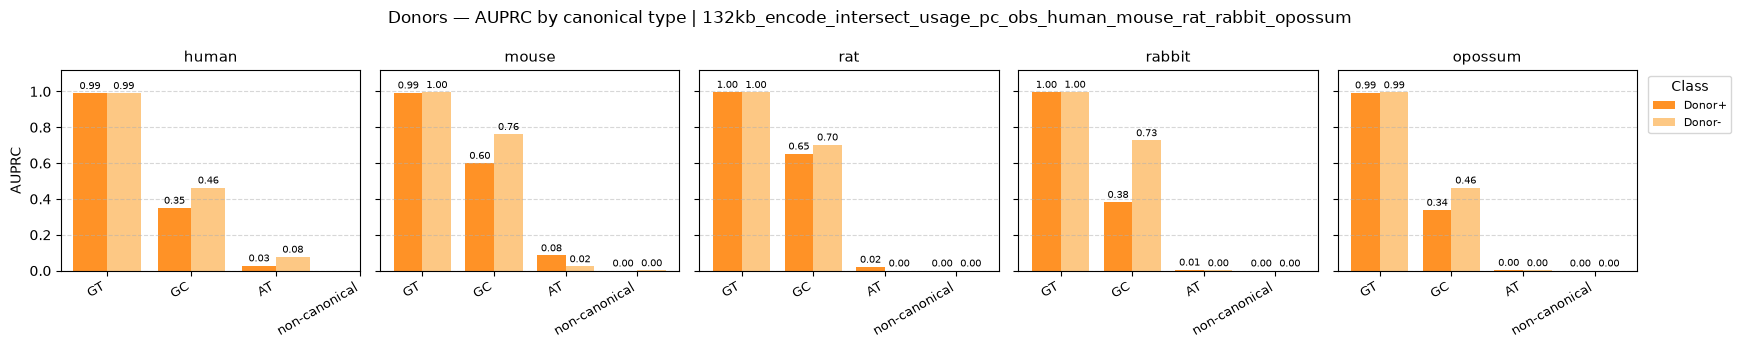

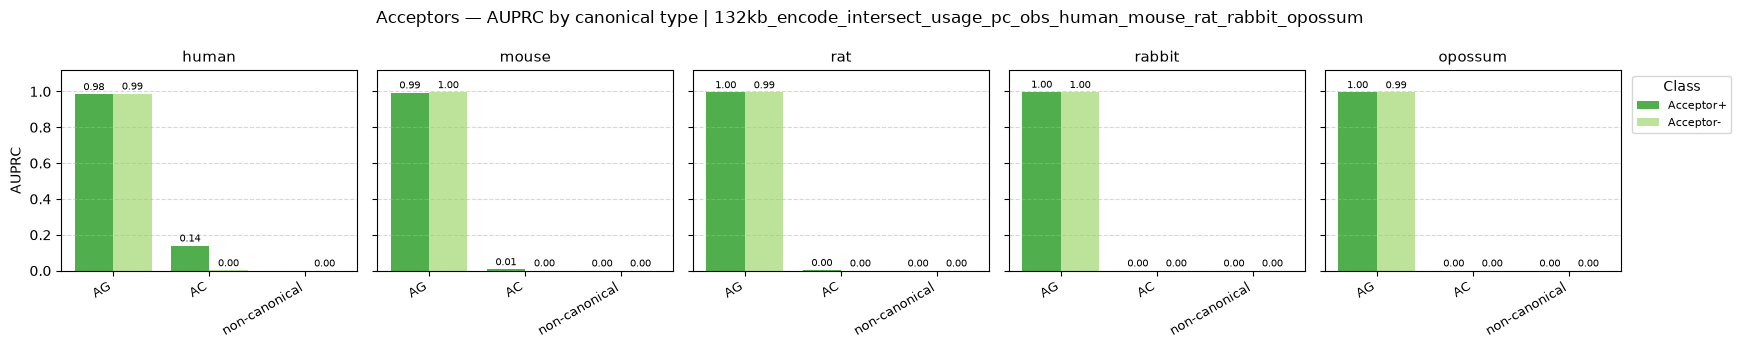

In [20]:
species_plot = [s for s in SPECIES_ORDER if s in auprc_df["species"].unique()]
n_species    = len(species_plot)

# Separate donor and acceptor panels
family_specs = [
    ("Donors",    ["Donor+", "Donor-"],       DONOR_TYPES),
    ("Acceptors", ["Acceptor+", "Acceptor-"], ACCEPTOR_TYPES),
]

metric = "auprc"  # or "auprc_norm"

for family_name, class_names, cat_order in family_specs:
    sub = auprc_df[auprc_df["class"].isin(class_names)].copy()
    sub["canonical_type"] = pd.Categorical(sub["canonical_type"], categories=cat_order, ordered=True)

    # Colors: one per class
    class_colors = {
        cn: CLASS_COLORS[idx]
        for idx, cn in enumerate(SPLICE_CLASS_NAMES)
        if cn in class_names
    }

    fig, axes = plt.subplots(
        1, n_species,
        figsize=(n_species * 3.5, 3.5),
        sharey=True,
        squeeze=False,
    )
    axes = axes[0]

    x = np.arange(len(cat_order))
    bar_width = 0.8 / max(len(class_names), 1)

    for ax, sp in zip(axes, species_plot):
        sp_sub = sub[sub["species"] == sp]

        for j, cn in enumerate(class_names):
            cn_sub = sp_sub[sp_sub["class"] == cn].set_index("canonical_type")
            vals   = [cn_sub.loc[cat, metric] if cat in cn_sub.index else np.nan
                      for cat in cat_order]
            offsets = x + (j - (len(class_names) - 1) / 2) * bar_width
            bars = ax.bar(
                offsets, vals,
                width=bar_width,
                color=class_colors[cn],
                label=cn,
                alpha=0.85,
            )
            for bar, v in zip(bars, vals):
                if np.isfinite(v):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        v + 0.01,
                        f"{v:.2f}",
                        ha="center", va="bottom", fontsize=7,
                    )

        ax.set_title(sp, fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels(cat_order, rotation=30, ha="right", fontsize=9)
        ax.set_ylim(0, 1.12)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

    axes[0].set_ylabel("AUPRC")
    axes[-1].legend(
        title="Class",
        bbox_to_anchor=(1.02, 1), loc="upper left",
        fontsize=8,
    )
    plt.suptitle(f"{family_name} — AUPRC by canonical type | {model}", fontsize=12)
    plt.tight_layout()

    fig.savefig(
        os.path.join(model_dir, pred_dir, f"auprc_canonical_type_{family_name.lower()}.png"),
        dpi=300, bbox_inches="tight",
    )
    plt.show()

#### Heatmap — AUPRC across species, class, and canonical type

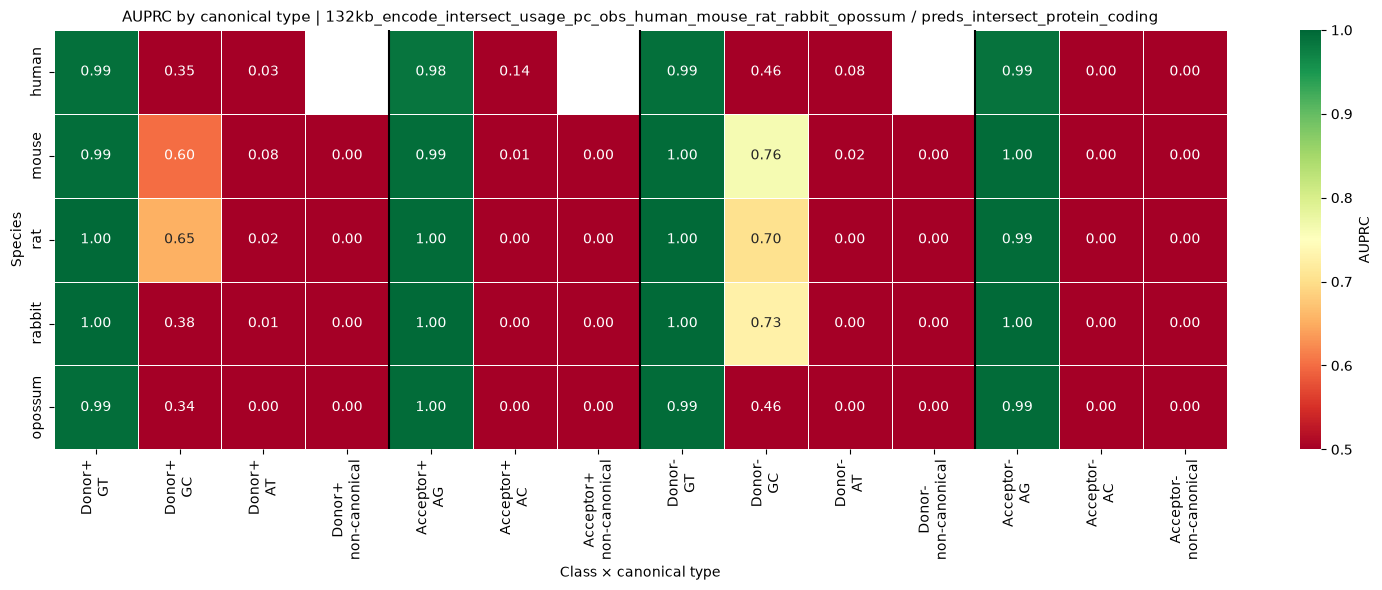

In [22]:
species_plot = [s for s in SPECIES_ORDER if s in auprc_df["species"].unique()]

# Build column labels: class × canonical_type
row_order = [
    (cn, ct)
    for cn in SPLICE_CLASS_NAMES
    for ct in CANONICAL_CATEGORIES[cn]
]
col_labels = [f"{cn}\n{ct}" for cn, ct in row_order]

mat = np.full((len(species_plot), len(row_order)), np.nan)
for r, sp in enumerate(species_plot):
    sp_sub = auprc_df[auprc_df["species"] == sp].set_index(["class", "canonical_type"])
    for c, (cn, ct) in enumerate(row_order):
        try:
            mat[r, c] = sp_sub.loc[(cn, ct), "auprc"]
        except KeyError:
            pass

mat_df = pd.DataFrame(mat, index=species_plot, columns=col_labels)

fig, ax = plt.subplots(figsize=(len(row_order) * 1.1, len(species_plot) * 1.0 + 1.0))

sns.heatmap(
    mat_df,
    ax=ax,
    cmap="RdYlGn",
    vmin=0.5, vmax=1.0,
    annot=True, fmt=".2f",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "AUPRC"},
)

# Vertical separators between class groups
boundaries = []
cumsum = 0
for cn in SPLICE_CLASS_NAMES:
    cumsum += len(CANONICAL_CATEGORIES[cn])
    boundaries.append(cumsum)
for b in boundaries[:-1]:
    ax.axvline(b, color="black", linewidth=1.5)

ax.set_xlabel("Class × canonical type")
ax.set_ylabel("Species")
plt.title(f"AUPRC by canonical type | {model} / {pred_dir}", fontsize=11)
plt.tight_layout()

fig.savefig(
    os.path.join(model_dir, pred_dir, "auprc_canonical_type_heatmap.png"),
    dpi=300, bbox_inches="tight",
)
plt.show()

#### Site count by canonical type

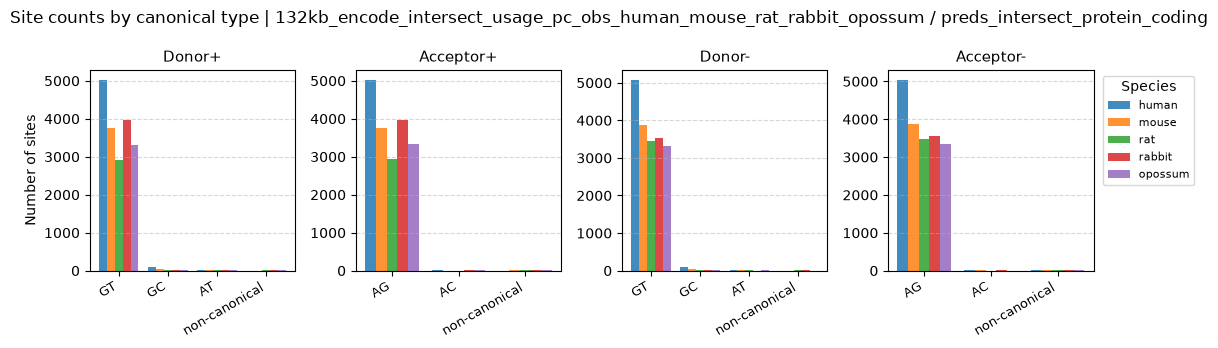

In [23]:
species_plot = [s for s in SPECIES_ORDER if s in auprc_df["species"].unique()]

fig, axes = plt.subplots(
    1, len(SPLICE_CLASS_NAMES),
    figsize=(len(SPLICE_CLASS_NAMES) * 3.0, 3.5),
    sharey=False, squeeze=False,
)
axes = axes[0]

for ax, (class_idx, class_name) in zip(axes, enumerate(SPLICE_CLASS_NAMES)):
    sub = auprc_df[auprc_df["class"] == class_name]
    cat_order_cls = CANONICAL_CATEGORIES[class_name]
    x = np.arange(len(cat_order_cls))
    bar_width = 0.8 / max(len(species_plot), 1)
    colors = sns.color_palette("tab10", n_colors=len(species_plot))

    for k, sp in enumerate(species_plot):
        sp_sub = sub[sub["species"] == sp].set_index("canonical_type")
        vals = [
            sp_sub.loc[cat, "n_positives"] if cat in sp_sub.index else 0
            for cat in cat_order_cls
        ]
        offsets = x + (k - (len(species_plot) - 1) / 2) * bar_width
        ax.bar(offsets, vals, width=bar_width, color=colors[k], label=sp, alpha=0.85)

    ax.set_title(class_name, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(cat_order_cls, rotation=30, ha="right", fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

axes[0].set_ylabel("Number of sites")
axes[-1].legend(
    title="Species",
    bbox_to_anchor=(1.02, 1), loc="upper left",
    fontsize=8,
)
plt.suptitle(f"Site counts by canonical type | {model} / {pred_dir}", fontsize=12)
plt.tight_layout()

fig.savefig(
    os.path.join(model_dir, pred_dir, "n_sites_by_canonical_type.png"),
    dpi=300, bbox_inches="tight",
)
plt.show()

#### Normalised AUPRC — compare canonical types across species

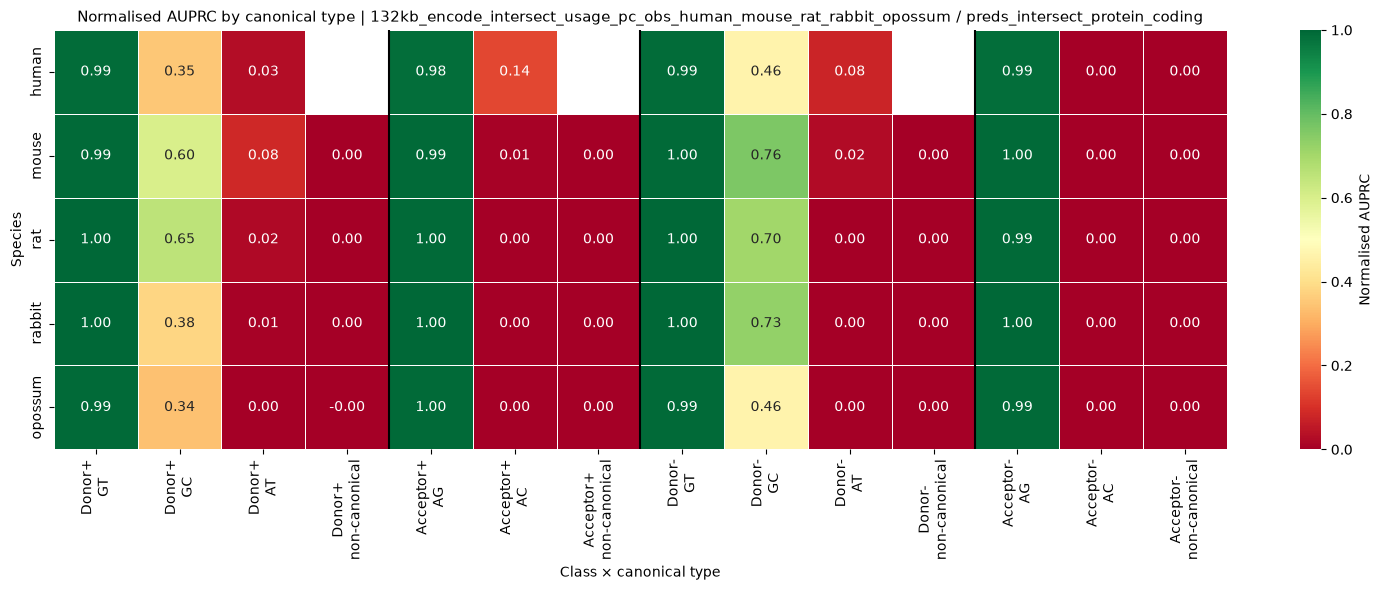

In [24]:
# Normalised AUPRC heatmap
mat_norm = np.full((len(species_plot), len(row_order)), np.nan)
for r, sp in enumerate(species_plot):
    sp_sub = auprc_df[auprc_df["species"] == sp].set_index(["class", "canonical_type"])
    for c, (cn, ct) in enumerate(row_order):
        try:
            mat_norm[r, c] = sp_sub.loc[(cn, ct), "auprc_norm"]
        except KeyError:
            pass

mat_norm_df = pd.DataFrame(mat_norm, index=species_plot, columns=col_labels)

fig, ax = plt.subplots(figsize=(len(row_order) * 1.1, len(species_plot) * 1.0 + 1.0))

sns.heatmap(
    mat_norm_df,
    ax=ax,
    cmap="RdYlGn",
    vmin=0.0, vmax=1.0,
    annot=True, fmt=".2f",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Normalised AUPRC"},
)

for b in boundaries[:-1]:
    ax.axvline(b, color="black", linewidth=1.5)

ax.set_xlabel("Class × canonical type")
ax.set_ylabel("Species")
plt.title(f"Normalised AUPRC by canonical type | {model} / {pred_dir}", fontsize=11)
plt.tight_layout()

fig.savefig(
    os.path.join(model_dir, pred_dir, "auprc_norm_canonical_type_heatmap.png"),
    dpi=300, bbox_inches="tight",
)
plt.show()

### Example class probabilities along a genomic region

Plot the predicted class probabilities for every scored position within a list of short
genomic intervals.  Each region is drawn as a two-panel figure (stacked splice-class
probabilities on top, background probability below) and all figures are saved to a single
PDF.  True splice sites are marked with shaped symbols above the bar; the dinucleotide is
printed below each labelled position.

In [11]:
import re

# List of (region_string, label) — coordinates are 0-based, end exclusive
regions = [
    ("mouse 11:96134855-96134889", "TG acceptor (non-canonical U2)"),
    ("mouse 5:117689540-117689572", "GG acceptor (non-canonical U2)"),
    ("mouse 5:117099522-117099553", "AC acceptor (U12)"),
    ("mouse 3:68990947-68990982",   "AC acceptor (U12)"),
    ("mouse 5:23805711-23805783",   "GT donor (U12)"),
    ("mouse 3:142538685-142538745", "AG acceptor (U12)"),
]

def parse_region(s):
    """Parse 'species chrom:start-end' into (species, chrom, start, end)."""
    m = re.match(r"^(\w+)\s+(\S+):(\d+)[-–](\d+)", s.strip().rstrip("."))
    if not m:
        raise ValueError(f"Cannot parse region: {s!r}")
    return m.group(1), m.group(2), int(m.group(3)), int(m.group(4))

No scored positions found: mouse 11:96134855-96134889
No scored positions found: mouse 5:117689540-117689572
No scored positions found: mouse 5:117099522-117099553
No scored positions found: mouse 3:68990947-68990982
No scored positions found: mouse 5:23805711-23805783
60 positions — mouse 3:142538685-142538745  [AG acceptor (U12)]


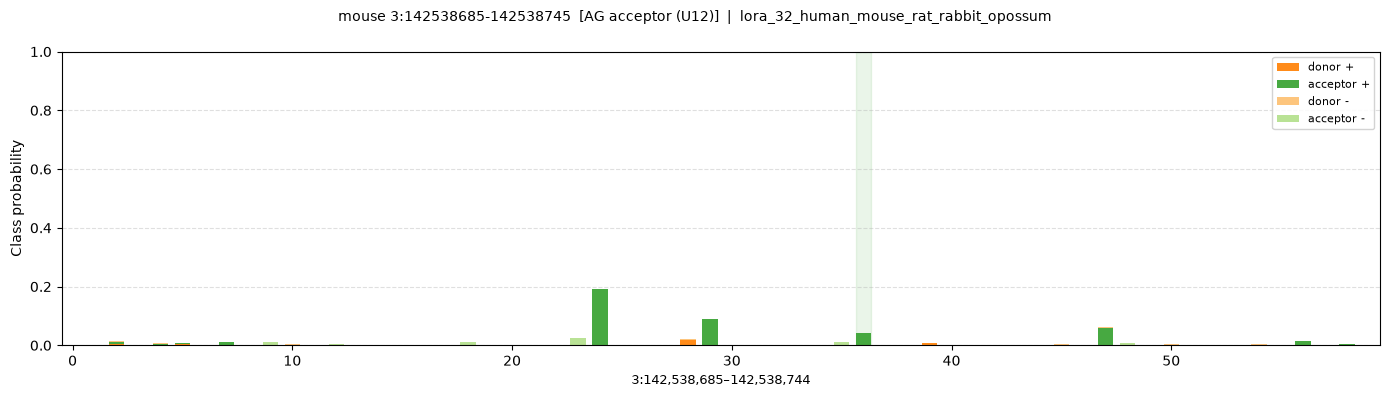


Saved all regions to /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/preds_all_intersect_protein_coding/region_probs_examples.pdf


In [15]:
from matplotlib.backends.backend_pdf import PdfPages


def plot_region_probs(df_region, title=""):
    """Single-panel figure: stacked splice-class probabilities per position."""
    prob_cols = [f"prob_{i}" for i in range(4)]
    n_pos     = len(df_region)
    xs        = np.arange(n_pos)
    bar_w     = 0.7

    class_probs = df_region[prob_cols].to_numpy()

    fig, ax = plt.subplots(figsize=(max(n_pos * 0.2 + 2, 8), 4))

    # shaded background for true splice sites
    for idx, row in df_region.iterrows():
        lbl = int(row["class_label"])
        if lbl < 4:
            ax.axvspan(
                idx - bar_w / 2, idx + bar_w / 2,
                color=CLASS_COLORS[lbl], alpha=0.1, zorder=0,
            )

    # stacked class probability bars
    bottoms = np.zeros(n_pos)
    for i, class_name in enumerate(SPLICE_CLASS_NAMES):
        ax.bar(
            xs, class_probs[:, i],
            bottom=bottoms,
            width=bar_w,
            color=CLASS_COLORS[i],
            label=CLASS_LABELS[i],
            alpha=0.9,
        )
        bottoms += class_probs[:, i]

    ax.set_ylim(0, 1.0)
    ax.set_xlim(-0.5, n_pos - 0.5)
    ax.set_ylabel("Class probability")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend(loc="upper right", fontsize=8, framealpha=0.85)

    #ax.set_xticks([])
    pos_start = df_region["position"].iloc[0]
    pos_end   = df_region["position"].iloc[-1]
    ax.set_xlabel(
        f"{df_region.iloc[0]['chrom']}:{pos_start:,}–{pos_end:,}",
        fontsize=9,
    )

    plt.suptitle(title, fontsize=10)
    plt.tight_layout()
    return fig


# ── iterate over all regions, display inline and collect into a PDF ──────────
pdf_path = os.path.join(model_dir, pred_dir, "region_probs_examples.pdf")

with PdfPages(pdf_path) as pdf:
    for region_str, label in regions:
        try:
            sp, ch, s, e = parse_region(region_str)
        except ValueError as exc:
            print(f"Skipping — {exc}")
            continue

        if sp not in canonical_preds:
            print(f"[{sp}] not in canonical_preds, skipping {region_str}")
            continue

        df_region = (
            canonical_preds[sp]
            .query("chrom == @ch and @s <= position < @e")
            .sort_values("position")
            .reset_index(drop=True)
        )

        if df_region.empty:
            print(f"No scored positions found: {region_str}")
            continue

        print(f"{len(df_region)} positions — {region_str}  [{label}]")
        fig = plot_region_probs(
            df_region,
            title=f"{region_str}  [{label}]  |  {model}",
        )
        pdf.savefig(fig, bbox_inches="tight")
        plt.show()
        plt.close(fig)

print(f"\nSaved all regions to {pdf_path}")